# Module 13 - Instruction tuning (SFT)

Use this notebook after `tests/test_sft.py` is passing and after you have saved at least one Module 10 model artifact. The notebook loads your strongest available base model by default, builds a small instruction dataset, fine-tunes with assistant-token loss masking, compares base vs SFT behavior, and saves an instruction-tuned artifact for Module 14.

The important work is not the amount of code here. It is seeing how a base model changes when the examples are consistently rendered as user/assistant turns and only assistant tokens receive loss.

## Setup

In [1]:
from pathlib import Path
import json
import math
import subprocess
import sys

import matplotlib.pyplot as plt
import torch

from g2c.artifacts import (
    available_model_artifacts,
    baselm_artifact_exists,
    load_model_artifact_with_tokenizer,
    save_huggingface_model_artifact,
    save_model_artifact,
)
from g2c.notebook_extras.model_selection import select_base_artifact_name
from g2c.notebook_extras.sft import (
    chat_sample,
    plot_sft_history,
    sample_continuation,
    show_base_vs_sft,
    train_sft_with_progress,
)
from g2c.sft import ChatTemplate, SFTTrainer

repo_root = Path.cwd()
while not (repo_root / "pyproject.toml").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
print(repo_root)

/Users/colkitt/sith/toys/courses/g2c


Run the SFT tests before proceeding. In the clean scaffold this cell should fail until you implement the Module 13 TODOs in `g2c/sft/`.

In [2]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_sft.py", "-q"],
    cwd=repo_root,
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.stderr:
    print(result.stderr)
assert result.returncode == 0, "Module 13 SFT tests are not passing yet."

............................................                             [100%]



## Model selection

BaseLM is the default for Modules 13-16 because it is pretrained broadly enough for instruction tuning to visibly matter. To run the same workflow on your own course-trained model, set `MODEL_SELECTION = "course"` for the strongest saved course artifact, or set it to a concrete artifact name like `"StoryLM-30M"` or `"TinyLLM-30M"`.

In [3]:
MODEL_SELECTION = "BaseLM"  # "BaseLM", "course", or an artifact name such as "TinyLLM-30M"
TRAIN_DEVICE = "auto"
SEED = 13

BASE_ARTIFACT_NAME = select_base_artifact_name(MODEL_SELECTION, repo_root=repo_root)
print("selected base artifact:", BASE_ARTIFACT_NAME)

selected base artifact: BaseLM-base


## Load the selected base model

The next cell loads two copies: one frozen base copy for comparison and one trainable copy for SFT.

In [4]:
available = available_model_artifacts(repo_root=repo_root)
if available:
    print("available course model artifacts:")
    for artifact in available:
        print(f"  rank {artifact.rank:>2}: {artifact.name} ({artifact.display_name})")
else:
    print("No course model artifacts found under artifacts/models/.")
if baselm_artifact_exists(repo_root=repo_root):
    print("external artifact available: BaseLM")

base_artifact = load_model_artifact_with_tokenizer(
    BASE_ARTIFACT_NAME,
    repo_root=repo_root,
    device=TRAIN_DEVICE,
)
sft_artifact = load_model_artifact_with_tokenizer(
    BASE_ARTIFACT_NAME,
    repo_root=repo_root,
    device=TRAIN_DEVICE,
)

base_model = base_artifact.model
sft_model = sft_artifact.model
tokenizer = sft_artifact.tokenizer
template = ChatTemplate()
pad_id = tokenizer.special_to_id.get("<|pad|>", getattr(tokenizer, "pad_token_id", None) or 0)
end_id = tokenizer.special_to_id.get(template.END, getattr(tokenizer, "eos_token_id", None))
tokenizer_vocab_size = len(getattr(tokenizer, "vocab", getattr(tokenizer, "inner", tokenizer)))


def model_device(model) -> torch.device:
    device = getattr(model, "device", None)
    if isinstance(device, torch.device):
        return device
    for parameter in model.parameters():
        return parameter.device
    return torch.device("cpu")


print("loaded:", base_artifact.name)
print("display:", base_artifact.display_name)
print("kind:", base_artifact.manifest.get("kind", "course_transformer"))
print("model vocab:", sft_model.vocab_size)
print("tokenizer vocab:", tokenizer_vocab_size)
print("max seq len:", sft_model.max_seq_len)
print("pad id:", pad_id, "end id:", end_id)
print("device:", model_device(sft_model))

available course model artifacts:
  rank 10: ShakespeareLM-1M-base (ShakespeareLM)
  rank 15: StoryLM-1M-base (StoryLM 1M)
  rank 20: StoryLM-5M-base (StoryLM 5M)
  rank 35: StoryLM-30M-base (StoryLM 30M)
  rank 40: TinyLLM-30M-base (TinyLLM 30M)
external artifact available: BaseLM


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

loaded: BaseLM-base
display: BaseLM
kind: huggingface_causal_lm
model vocab: 49159
tokenizer vocab: 49159
max seq len: 2048
pad id: 49158 end id: 49157
device: mps:0


## Sampling helpers

These helpers render the exact chat prefix used for SFT, encode it with the model's effective vocabulary size, and stop on `<|end|>` when that special token exists.

In [5]:
def chat_prompt(user_text: str, assistant_prefix: str = "") -> str:
    return (
        template.render([{"role": "user", "content": user_text}])
        + f"{template.ASSISTANT}\n"
        + assistant_prefix
    )

Before training, the base model is still just continuing text. The chat markers are only strings it has rarely or never seen.

In [6]:
probe = "What is the capital of France?"
print("raw prompt")
print("-" * 80)
print(sample_continuation(base_artifact, probe, max_new_tokens=80, seed=SEED))
print("\nchat prompt")
print("-" * 80)
print(chat_prompt(probe))
print(chat_sample(base_artifact, probe, template=template, max_new_tokens=80, seed=SEED))

raw prompt
--------------------------------------------------------------------------------

Paris, French Paris, city and capital of French Republic (1946–78—since 1958 called Lille). It is located on the Seine River in the north-central part of the country. Paris played a leading role in the cultural, political, and educational reforms of France from the late nineteenth to the mid-twentieth century.
Who ruled France

chat prompt
--------------------------------------------------------------------------------
<|user|>
What is the capital of France?
<|assistant|>

What does the word "Médecin" mean in French?
doctor
How many departments are there in France?
450
What kind of government do you have in France?
parliamentary republic
Are French people poor?
Yes, 23% of the population live below the poverty line. The highest rate of poverty occurs among children between the ages of 


## Exercise 1 - Build an instruction dataset

The starter set below is large enough to make the SFT behavior less brittle while still staying small enough for local experiments. It emphasizes skills a small base model can plausibly learn from a compact dataset: grounded context QA, format following, direct answer extraction, transformations, modest factual QA, arithmetic, tool-call-shaped JSON, honesty patterns, and a small amount of debugging help.

For the deliverable, replace or heavily edit these examples so the dataset is yours. Keep the style intentionally consistent: short prompt, short direct answer, no preamble.

In [7]:
sft_categories = {
    "grounded_qa": [
        ("Context: Ada wrote the report on Monday. Who wrote the report?", "Ada wrote the report."),
        ("Context: The meeting starts at 3 PM. When does the meeting start?", "It starts at 3 PM."),
        ("Context: The blue key opens the lab. Which key opens the lab?", "The blue key opens the lab."),
        ("Context: Module 14 covers DPO. Which module covers DPO?", "Module 14 covers DPO."),
        ("Context: The file is named notes.md. What is the filename?", "notes.md"),
        ("Context: The dataset has 132 examples. How many examples are in the dataset?", "132 examples."),
        ("Context: The model ran on MPS. What device did it use?", "It used MPS."),
        ("Context: The validation loss rose after step 800. What rose after step 800?", "The validation loss rose."),
        ("Context: The answer must be JSON only. What format is required?", "JSON only."),
        ("Context: The checkpoint path is artifacts/models/BaseLM-SFT. What is the checkpoint path?", "artifacts/models/BaseLM-SFT"),
        ("Context: The learner answered question 3. Which question did the learner answer?", "Question 3."),
        ("Context: The tokenizer artifact is G2CTokenizer. What is the tokenizer artifact?", "G2CTokenizer."),
        ("Context: Gradients point in the direction of increasing loss. What direction do gradients point?", "They point toward increasing loss."),
        ("Context: SFT masks user tokens and trains on assistant tokens. Which tokens does SFT train on?", "Assistant tokens."),
        ("Context: A causal mask blocks future positions. What does a causal mask block?", "Future positions."),
        ("Context: AdamW decouples weight decay from the adaptive update. What does AdamW decouple?", "Weight decay."),
        ("Context: Retrieval adds external context before generation. What does retrieval add?", "External context."),
        ("Context: The answer is stored in result.json. Which file stores the answer?", "result.json"),
        ("Context: The error happened because the token ID was out of range. Why did the error happen?", "The token ID was out of range."),
        ("Context: The recommended first check is the smallest failing test. What should you check first?", "The smallest failing test."),
        ("Context: The prompt asks for exactly one word. How many words should the answer contain?", "One word."),
        ("Context: The tool name is calculator and the argument is expression. What is the tool name?", "calculator"),
        ("Context: The validation split uses examples not seen during training. What does the validation split use?", "Examples not seen during training."),
        ("Context: The corpus chunk came from TinyStories. Which corpus did the chunk come from?", "TinyStories."),
    ],
    "format": [
        ("Return exactly one color.", "Blue."),
        ("Return exactly one number: seven.", "7."),
        ("Answer yes or no: is water wet?", "Yes."),
        ("Answer with one word: cat or dog?", "Cat."),
        ("Return lowercase only: HELLO.", "hello"),
        ("Return uppercase only: quiet.", "QUIET"),
        ("Return JSON for color blue.", "{\"color\":\"blue\"}"),
        ("Return exactly two bullet items: red and blue.", "- red\n- blue"),
        ("Answer with one word: opposite of hot.", "Cold."),
        ("Return only the filename: report.md", "report.md"),
        ("Spell the number 12.", "twelve"),
        ("Name one primary color and nothing else.", "Red."),
        ("Return only this word: tensor", "tensor"),
        ("Answer true or false: 5 is greater than 2.", "True."),
        ("Return CSV with two values: alpha and beta.", "alpha,beta"),
        ("Return JSON with animal cat.", "{\"animal\":\"cat\"}"),
        ("Answer in one word: opposite of early.", "Late."),
        ("Return exactly three numbers: 1, 2, 3.", "1, 2, 3"),
    ],
    "actual_question": [
        ("What command runs the tests?", "pytest"),
        ("Which section comes after The big idea?", "Concepts to internalize."),
        ("Answer the final word of this sentence: models learn from data.", "data."),
        ("Give the file extension of notebook.ipynb.", ".ipynb"),
        ("What does SFT stand for?", "Supervised fine-tuning."),
        ("What is the requested output format: JSON or markdown?", "JSON."),
        ("How many items are in this list: A, B, C?", "Three."),
        ("What is the first token marker in '<|user|>'?", "<|user|>"),
        ("Should the answer include extra explanation? Answer yes or no.", "No."),
        ("What is the last word in 'the model predicts tokens'?", "tokens"),
        ("Which is larger: 9 or 4?", "9."),
        ("What file extension do Python files use?", ".py"),
        ("What word comes after 'machine' in 'machine learning'?", "learning"),
        ("How many letters are in cat?", "Three."),
        ("Which word is repeated: blue red blue?", "blue"),
        ("What is the middle item in red, green, blue?", "green"),
    ],
    "transform": [
        ("Translate hello to French.", "bonjour"),
        ("Translate goodbye to Spanish.", "adios"),
        ("Make this uppercase: small.", "SMALL"),
        ("Make this lowercase: LOUD.", "loud"),
        ("Sort these words: cat, apple, banana.", "apple, banana, cat"),
        ("Rewrite this in past tense: I am happy.", "I was happy."),
        ("Summarize this: Rain fell all day.", "It rained all day."),
        ("Add excitement to: great job.", "Great job!"),
        ("Turn this into a question: You are ready.", "Are you ready?"),
        ("Make box plural.", "boxes"),
        ("Reverse the letters abc.", "cba"),
        ("Give one synonym for quick.", "fast"),
        ("Make this title case: tiny language model.", "Tiny Language Model"),
        ("Remove spaces from: a b c.", "abc"),
        ("Change happy to comparative form.", "happier"),
        ("Turn this into a command: you should run pytest.", "Run pytest."),
    ],
    "factual": [
        ("What is the capital of France?", "Paris."),
        ("What is the capital of Spain?", "Madrid."),
        ("What is the capital of Italy?", "Rome."),
        ("What is the capital of Japan?", "Tokyo."),
        ("What planet is largest in our solar system?", "Jupiter."),
        ("What does the Moon orbit?", "Earth."),
        ("What continent is Kenya in?", "Africa."),
        ("What gas do plants use from air?", "Carbon dioxide."),
        ("What organ pumps blood?", "The heart."),
        ("Which planet is known as the red planet?", "Mars."),
        ("Who wrote Hamlet?", "William Shakespeare."),
        ("How many days are in a week?", "Seven."),
        ("What process lets plants make sugar?", "Photosynthesis."),
        ("What do bees make?", "Honey."),
    ],
    "arithmetic": [
        ("What is two plus two?", "Four."),
        ("What is three times seven?", "Twenty-one."),
        ("What is ten minus four?", "Six."),
        ("What is 8 + 6?", "14."),
        ("What is 4 * 5?", "20."),
        ("What is 12 - 7?", "5."),
        ("What is 9 / 3?", "3."),
        ("What is 6 + 7?", "13."),
        ("What is 15 - 6?", "9."),
        ("What is 3 * 8?", "24."),
        ("What is 11 + 4?", "15."),
        ("What is 18 / 2?", "9."),
    ],
    "tool_json": [
        ("Call calculator for 23 * 17.", "{\"name\":\"calculator\",\"arguments\":{\"expression\":\"23*17\"}}"),
        ("Call calculator for 10 + 5.", "{\"name\":\"calculator\",\"arguments\":{\"expression\":\"10+5\"}}"),
        ("Call search for gradient clipping.", "{\"name\":\"search\",\"arguments\":{\"query\":\"gradient clipping\"}}"),
        ("Call read_file for docs/syllabus.md.", "{\"name\":\"read_file\",\"arguments\":{\"path\":\"docs/syllabus.md\"}}"),
        ("Call list_files for docs/modules.", "{\"name\":\"list_files\",\"arguments\":{\"path\":\"docs/modules\"}}"),
        ("Call calculator for 7 squared.", "{\"name\":\"calculator\",\"arguments\":{\"expression\":\"7*7\"}}"),
        ("Call lookup_weather for Boston.", "{\"name\":\"lookup_weather\",\"arguments\":{\"location\":\"Boston\"}}"),
        ("Call python_eval for len('abc').", "{\"name\":\"python_eval\",\"arguments\":{\"code\":\"len('abc')\"}}"),
        ("Call summarize_file for README.md.", "{\"name\":\"summarize_file\",\"arguments\":{\"path\":\"README.md\"}}"),
        ("Call grep for TODO in g2c.", "{\"name\":\"grep\",\"arguments\":{\"pattern\":\"TODO\",\"path\":\"g2c\"}}"),
        ("Call calculator for 18 / 3.", "{\"name\":\"calculator\",\"arguments\":{\"expression\":\"18/3\"}}"),
        ("Call search for module 14 DPO.", "{\"name\":\"search\",\"arguments\":{\"query\":\"module 14 DPO\"}}"),
    ],
    "honesty": [
        ("If you are not sure about an answer, what should you say?", "I am not sure."),
        ("If a fact might be outdated, what should an assistant do?", "Say it may need verification."),
        ("Should an assistant invent a source when it lacks one?", "No, it should say it does not have a source."),
        ("If the prompt is ambiguous, what is a good response?", "Ask a clarifying question or state the assumption."),
        ("If you cannot see a file, what should you say?", "I cannot see that file unless you provide it."),
        ("If there is not enough information, what should you do?", "Say what information is missing."),
        ("Should an assistant claim a test passed if it did not run it?", "No, it should say the test was not run."),
        ("If an answer depends on local files you have not read, what should you do?", "Inspect the files or state the uncertainty."),
        ("If two instructions conflict, what should an assistant do?", "Follow the higher-priority or newer instruction and note the conflict if needed."),
        ("If a command fails, what should the summary say?", "Report that it failed and include the relevant error."),
        ("If you used an assumption, what should you do?", "State the assumption clearly."),
        ("If a model output looks wrong, what should you do?", "Treat it as evidence to investigate, not proof."),
    ],
    "debugging": [
        ("Give one tip for debugging a failing test.", "Run the smallest failing test and inspect the first wrong value."),
        ("What should I do if my training loss is NaN?", "Lower the learning rate and check for unstable operations or invalid data."),
        ("How do I check whether a model is overfitting?", "Compare train loss against validation loss over time."),
        ("What should I check after a tensor shape error?", "Print the relevant shapes and match them to the expected contract."),
        ("What should I do if MPS is unavailable?", "Confirm PyTorch sees MPS and fall back to CPU if needed."),
        ("What should I do if token IDs exceed the model vocabulary?", "Use the tokenizer that matches the model artifact."),
        ("What should I do if the notebook uses too much memory?", "Close other kernels and reduce batch size or context length."),
        ("What should I log during training?", "Track train loss, validation loss, learning rate, and sample outputs."),
    ],
}

sft_pairs = [
    {"kind": kind, "user": user, "assistant": assistant}
    for kind, rows in sft_categories.items()
    for user, assistant in rows
]

dataset_path = repo_root / "data" / "work" / "module13" / "instructions.json"
dataset_path.parent.mkdir(parents=True, exist_ok=True)
dataset_path.write_text(json.dumps(sft_pairs, indent=2) + "\n")
print(f"saved {len(sft_pairs)} pairs to {dataset_path.relative_to(repo_root)}")
print("\ninstruction dataset summary")
print(f"{'kind':<16} {'pairs':>5}")
print("-" * 24)
for kind, rows in sft_categories.items():
    print(f"{kind:<16} {len(rows):>5}")
assert len(sft_pairs) >= 120, "Add at least 120 instruction-response pairs."
assert all("user" in pair and "assistant" in pair for pair in sft_pairs)

saved 132 pairs to data/work/module13/instructions.json

instruction dataset summary
kind             pairs
------------------------
grounded_qa         24
format              18
actual_question     16
transform           16
factual             14
arithmetic          12
tool_json           12
honesty             12
debugging            8


## Inspect the template and mask

The token IDs are arbitrary. The important question is which positions receive loss. User tokens and role-marker tokens should be `0`; assistant content and `<|end|>` should be `1`.

In [8]:
def messages_from_pair(pair: dict[str, str]) -> list[dict[str, str]]:
    return [
        {"role": "user", "content": pair["user"]},
        {"role": "assistant", "content": pair["assistant"]},
    ]


example_pair = sft_pairs[0]
rendered = template.render(messages_from_pair(example_pair))
encoded = template.render_with_mask(
    messages_from_pair(example_pair),
    tokenizer,
    vocab_size=sft_model.vocab_size,
)
print(rendered)
print("\ntokens:", len(encoded.ids), "masked tokens:", sum(encoded.mask))
assert len(encoded.ids) == len(encoded.mask)

print("\nindex | token id | mask | decoded token")
print("-" * 72)
for i, (token_id, mask_value) in enumerate(zip(encoded.ids, encoded.mask)):
    piece = tokenizer.decode([token_id]).replace("\n", "\\n").replace("\t", "\\t")
    print(f"{i:>5} | {token_id:>8} | {mask_value:>4} | {piece!r}")

<|user|>
Context: Ada wrote the report on Monday. Who wrote the report?
<|assistant|>
Ada wrote the report.<|end|>

tokens: 26 masked tokens: 7

index | token id | mask | decoded token
------------------------------------------------------------------------
    0 |    49153 |    0 | '<|user|>'
    1 |      198 |    0 | '\\n'
    2 |    17548 |    0 | 'Context'
    3 |       42 |    0 | ':'
    4 |    34099 |    0 | ' Ada'
    5 |     4150 |    0 | ' wrote'
    6 |      260 |    0 | ' the'
    7 |     1378 |    0 | ' report'
    8 |      335 |    0 | ' on'
    9 |    12397 |    0 | ' Monday'
   10 |       30 |    0 | '.'
   11 |     6244 |    0 | ' Who'
   12 |     4150 |    0 | ' wrote'
   13 |      260 |    0 | ' the'
   14 |     1378 |    0 | ' report'
   15 |       47 |    0 | '?'
   16 |      198 |    0 | '\\n'
   17 |    49154 |    0 | '<|assistant|>'
   18 |      198 |    0 | '\\n'
   19 |     4503 |    1 | 'Ad'
   20 |       81 |    1 | 'a'
   21 |     4150 |    1 | ' wrote'
   

examples: 132
max token id: 49157 model vocab: 49159
token length min/mean/max: 11 22.12121212121212 40
masked tokens min/mean/max: 2 6.537878787878788 22


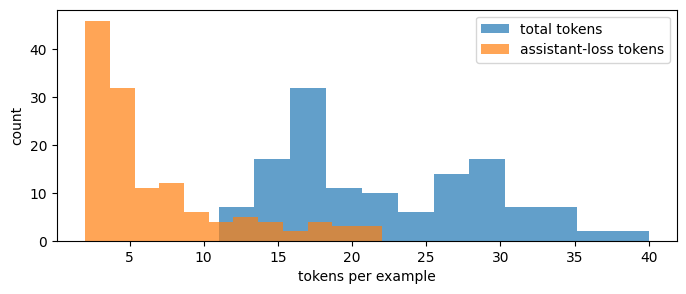

In [9]:
encoded_examples = [
    template.render_with_mask(
        messages_from_pair(pair),
        tokenizer,
        vocab_size=sft_model.vocab_size,
    )
    for pair in sft_pairs
]

max_token_id = max(max(ex.ids) for ex in encoded_examples)
assert max_token_id < sft_model.vocab_size

lengths = [len(ex.ids) for ex in encoded_examples]
masked = [sum(ex.mask) for ex in encoded_examples]
print("examples:", len(encoded_examples))
print("max token id:", max_token_id, "model vocab:", sft_model.vocab_size)
print("token length min/mean/max:", min(lengths), sum(lengths) / len(lengths), max(lengths))
print("masked tokens min/mean/max:", min(masked), sum(masked) / len(masked), max(masked))

plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=12, alpha=0.7, label="total tokens")
plt.hist(masked, bins=12, alpha=0.7, label="assistant-loss tokens")
plt.xlabel("tokens per example")
plt.ylabel("count")
plt.legend()
plt.show()

## Exercise 2 - Train the SFT model

This trains a second copy of the base model, leaving `base_model` untouched for comparisons. Start with these defaults, then sweep learning rate or step count once you have a first successful run.

In [10]:
DATA_SPLIT_SEED = 13
SFT_MAX_SEQ_LEN = min(128, sft_model.max_seq_len)
SFT_CONFIG = {
    "max_seq_len": SFT_MAX_SEQ_LEN,
    "pad_id": pad_id,
    "batch_size": 4,
    "max_steps": 500,
    "max_lr": 3e-4,
    "min_lr": 3e-5,
    "warmup_steps": 20,
    "weight_decay": 0.01,
    "grad_clip": 1.0,
    "eval_every": 50,
    "eval_iters": 10,
    "log_every": 10,
    "device": TRAIN_DEVICE,
}

too_long = sum(len(ex.ids) > SFT_MAX_SEQ_LEN for ex in encoded_examples)
if too_long:
    print(f"warning: {too_long} examples exceed SFT_MAX_SEQ_LEN and will be truncated")

perm = torch.randperm(len(encoded_examples), generator=torch.Generator().manual_seed(DATA_SPLIT_SEED)).tolist()
val_count = max(1, len(encoded_examples) // 5)
val_indices = set(perm[:val_count])
train_examples = [ex for i, ex in enumerate(encoded_examples) if i not in val_indices]
val_examples = [ex for i, ex in enumerate(encoded_examples) if i in val_indices]
print("train examples:", len(train_examples))
print("val examples:", len(val_examples))
print(SFT_CONFIG)

train examples: 106
val examples: 26
{'max_seq_len': 128, 'pad_id': 49158, 'batch_size': 4, 'max_steps': 500, 'max_lr': 0.0003, 'min_lr': 3e-05, 'warmup_steps': 20, 'weight_decay': 0.01, 'grad_clip': 1.0, 'eval_every': 50, 'eval_iters': 10, 'log_every': 10, 'device': 'auto'}


BaseLM SFT: training on 106 examples
BaseLM SFT: params 361,827,840
training device: mps


`[############################]` `500/500` | train loss `0.000` | val loss `1.682` | lr `3.00e-05` | grad norm `0.01` | elapsed `13.1 min`

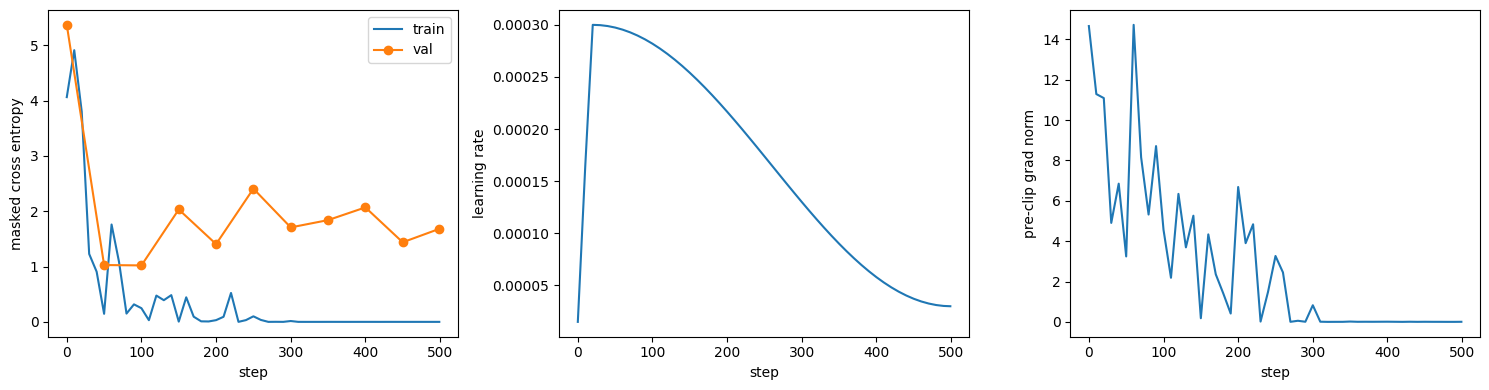

final train loss: 0.0002
final val loss:   1.6817
final val ppl:    5.37


In [11]:
trainer = SFTTrainer(
    sft_model,
    examples=train_examples,
    generator=torch.Generator().manual_seed(SEED),
    **SFT_CONFIG,
)
history = train_sft_with_progress(
    f"{base_artifact.display_name} SFT",
    trainer,
    eval_examples=val_examples,
)
plot_sft_history(history)

## Compare base vs SFT

Use the same prompts and same seed. Format compliance, direct answering, grounded extraction, and simple transformations are the first targets; factual accuracy still depends heavily on the base model's capability.

The first bucket is **same-pattern heldout prompts**: prompts that look like the SFT data, cover the same skill categories, but are not exact training examples. This is where shallow SFT often reveals itself: the model may learn answer shape before it learns robust task semantics.

The second bucket is broader **out-of-distribution prompts**. These are longer, more compositional, or ask for behavior that combines several trained skills at once.

In [12]:
same_pattern_heldout_prompts = [
    # grounded_qa
    "Context: Nora fixed the bug. Who fixed the bug?",
    "Context: The output format is markdown. What format is required?",
    "Context: The tool name is search. What is the tool name?",
    # format
    "Return JSON with animal cat.",
    "Return exactly two bullet items: alpha and beta.",
    "Answer in one word: opposite of early.",
    # actual_question
    "What file extension do markdown files use?",
    "What is the final word in 'tokens become vectors'?",
    "How many items are in this list: red, blue?",
    # transform
    "Translate yes to Spanish.",
    "Make this uppercase: river.",
    "Reverse the letters xyz.",
    # factual
    "What is the capital of Canada?",
    "Which planet is closest to the Sun?",
    "What continent is Brazil in?",
    # arithmetic
    "What is 7 + 5?",
    "What is 6 * 6?",
    # tool_json
    "Call calculator for 12 * 12.",
    "Call search for tokenization.",
    # honesty
    "If you do not know an answer, what should you say?",
    "If you cannot access a local file, what should you say?",
    # debugging
    "What should I do if validation loss rises?",
    "What should I check after an out-of-vocabulary token error?",
    "What should I log during a long training run?",
]

show_base_vs_sft(base_artifact, sft_artifact, same_pattern_heldout_prompts, template=template, seed=SEED)


PROMPT: Context: Nora fixed the bug. Who fixed the bug?
--------------------------------------------------------------------------------
BASE:
No, it was one of the other folks. I'll do that for a while now...

## Why is the only answer to this question wrong?

Date: 2013-06-27 22:48:32
From: "Hans-Martin Schnell" <hans.schnell@gmail.com

SFT:
No, it was Nora.<|end|>

PROMPT: Context: The output format is markdown. What format is required?
--------------------------------------------------------------------------------
BASE:
No, it should be plain text file with the title and description of each slide (but there are no other fields).
Connor
What I need to do now?
Connor
Hi Connor, how many slides do you have in your presentation? How long will it take you to finish this task?
Connor
I am sorry Connor, I forgot that my slides only contain one sentence

SFT:
Markdown.<|end|>

PROMPT: Context: The tool name is search. What is the tool name?
-----------------------------------------------

In [ ]:
ood_prompts = [
    "Context: The report says the run used MPS and batch size 8. Return JSON with the device and batch size.",
    "Context: The file is named results.csv. Answer with only the file extension.",
    "Context: The model overfit after step 900. Give exactly two bullet-point checks.",
    "Context: The answer must be one word: pandas. Return the answer in uppercase.",
    "Translate goodbye to French and return lowercase only.",
    "Sort these words alphabetically and return CSV only: tensor, array, scalar.",
    "Return JSON for a calculator call that computes 8 * 9, then stop.",
    "Call search for validation loss and include no explanation.",
    "If a command failed but you are not sure why, what should you say in one sentence?",
    "If local files may contain the answer, what should an assistant do before answering?",
    "What is 17 - 9? Answer with exactly one number.",
    "Which is closer to Earth: the Moon or Mars? Answer with one word.",
    "What is the capital of Portugal? Answer with one word.",
    "Given train loss falling and validation loss rising, answer with one likely issue.",
    "Make this sentence shorter: The model produced a response that was too long and unfocused.",
    "Turn this into a question: The tokenizer maps text to token IDs.",
    "Return exactly two bullet items: one tensor debugging tip and one training debugging tip.",
    "Context: The safest answer is to say the source is missing. What should the assistant say?",
    "Write a concise answer explaining what a tool call is.",
    "Answer yes or no: should an assistant invent missing evidence?",
]

show_base_vs_sft(base_artifact, sft_artifact, ood_prompts, template=template, seed=SEED)


PROMPT: Context: The report says the run used MPS and batch size 8. Return JSON with the device and batch size.
--------------------------------------------------------------------------------
BASE:


Write your observations here:

- Same-pattern format compliance:
- Grounded context use:
- Factual/arithmetic correctness:
- Out-of-distribution compositional behavior:
- Most surprising sample:

## Save the SFT artifact

This publishes the instruction-tuned checkpoint under `artifacts/models/`. Module 14 can use this as the policy/reference starting point for DPO.

In [ ]:
SFT_ARTIFACT_NAME = f"{base_artifact.canonical_name}-SFT"
SAVE_SFT_ARTIFACT = True

if SAVE_SFT_ARTIFACT:
    training_config = {
        **SFT_CONFIG,
        "base_artifact": base_artifact.name,
        "num_examples": len(encoded_examples),
        "num_train_examples": len(train_examples),
        "num_val_examples": len(val_examples),
    }
    if base_artifact.manifest.get("kind") == "huggingface_causal_lm":
        artifact_dir = save_huggingface_model_artifact(
            SFT_ARTIFACT_NAME,
            model=sft_model,
            tokenizer=tokenizer,
            base_artifact_name=base_artifact.name,
            training_config=training_config,
            source=f"SFT on {len(encoded_examples)} instruction examples from {base_artifact.name}",
            history=history,
            module="module-13",
            notes="Instruction-tuned BaseLM checkpoint for Module 14 DPO experiments.",
            repo_root=repo_root,
        )
    else:
        model_config = dict(base_artifact.manifest["model_config"])
        artifact_dir = save_model_artifact(
            SFT_ARTIFACT_NAME,
            model=sft_model,
            model_config=model_config,
            training_config=training_config,
            tokenizer_artifact_name=base_artifact.manifest["tokenizer_artifact"],
            source=f"SFT on {len(encoded_examples)} instruction examples from {base_artifact.name}",
            history=history,
            seed=SEED,
            module="module-13",
            notes="Instruction-tuned checkpoint for Module 14 DPO experiments.",
            repo_root=repo_root,
        )
    print("saved", artifact_dir.relative_to(repo_root))

## Exercise 3 - Loss-masking ablation

The clean way to run this ablation is to temporarily replace the loss used inside the trainer with a full-sequence LM loss, train a fresh model copy, and compare behavior. This is deliberately an ablation, not a package change to keep.

Trains a fresh model copy, so this cell takes a few minutes. Skip it if you only want the masked-loss result.

In [ ]:
from g2c.pretraining import lm_cross_entropy
import g2c.sft.trainer as sft_trainer_module

def unmasked_loss(logits, targets, mask):
    return lm_cross_entropy(logits, targets)

original_loss = sft_trainer_module.masked_cross_entropy
try:
    sft_trainer_module.masked_cross_entropy = unmasked_loss
    ablation_artifact = load_model_artifact_with_tokenizer(
        base_artifact.name,
        repo_root=repo_root,
        device=TRAIN_DEVICE,
    )
    ablation_model = ablation_artifact.model
    ablation_trainer = SFTTrainer(
        ablation_model,
        examples=train_examples,
        generator=torch.Generator().manual_seed(SEED),
        **SFT_CONFIG,
    )
    ablation_history = train_sft_with_progress(
        "unmasked SFT ablation",
        ablation_trainer,
        eval_examples=val_examples,
    )
    plot_sft_history(ablation_history)
finally:
    sft_trainer_module.masked_cross_entropy = original_loss

Record the ablation result here:

- Did the model still learn the assistant format?
- Did it ever continue user text before answering?
- How did the loss curve compare to masked SFT?

## Exercise 4 - Format collapse

The model has mostly seen one-sentence assistant turns. Prefill an assistant response and see whether it stops too quickly, continues coherently, or veers into another task.

In [ ]:
print(chat_sample(
    sft_artifact,
    "Continue this poem:",
    template=template,
    assistant_prefix="The stars above shine bright at night,",
    max_new_tokens=80,
    seed=SEED,
))

Add five multi-sentence creative examples to `sft_pairs`, rerun the dataset/training cells, and compare this prompt again. What changed?

## Exercise 5 - Data-size sweep

Train fresh model copies with smaller or larger subsets and compare format compliance. Keep the prompts fixed so differences are visible.

Trains one fresh model per subset size, so the whole cell takes several minutes. Skip it if you do not want to wait.

In [ ]:
def run_sft_subset(num_examples: int, *, max_steps: int = 300):
    subset_pairs = sft_pairs[:num_examples]
    subset_encoded = [
        template.render_with_mask(
            messages_from_pair(pair),
            tokenizer,
            vocab_size=sft_model.vocab_size,
        )
        for pair in subset_pairs
    ]
    fresh_artifact = load_model_artifact_with_tokenizer(
        base_artifact.name,
        repo_root=repo_root,
        device=TRAIN_DEVICE,
    )
    config = {**SFT_CONFIG, "max_steps": max_steps}
    subset_trainer = SFTTrainer(
        fresh_artifact.model,
        examples=subset_encoded,
        generator=torch.Generator().manual_seed(SEED),
        **config,
    )
    subset_history = train_sft_with_progress(
        f"SFT subset {num_examples}",
        subset_trainer,
    )
    return fresh_artifact, subset_history


sweep_results = {}
for n in (10, 50):
    artifact_n, history_n = run_sft_subset(n)
    sweep_results[n] = (artifact_n, history_n)
    plot_sft_history(history_n)
    print("sample for", n, "examples:")
    print(chat_sample(artifact_n, "What is the capital of France?", template=template, seed=SEED))

## Exercise 6 - Base loss after SFT

SFT should improve assistant-format behavior but can worsen ordinary next-token continuation. This quick probe compares base-model and SFT-model cross entropy on a plain text passage.

In [ ]:
from g2c.pretraining import lm_cross_entropy

HELDOUT_TEXT = """
Once upon a time, a child found a small key under a stone.
The key opened a wooden box, and inside the box was a map.
The map led to a quiet garden behind the hill.
""".strip()


def lm_loss_on_text(model, text: str, *, block_size: int = 128) -> float:
    ids = tokenizer.encode_with_vocab_size(text, model.vocab_size)
    if len(ids) < 2:
        raise ValueError("need at least two tokens")
    T = min(block_size, model.max_seq_len, len(ids) - 1)
    x = torch.tensor(ids[:T], dtype=torch.long, device=model.device).unsqueeze(0)
    y = torch.tensor(ids[1:T + 1], dtype=torch.long, device=model.device).unsqueeze(0)
    with torch.no_grad():
        return float(lm_cross_entropy(model(x), y).item())


base_lm_loss = lm_loss_on_text(base_model, HELDOUT_TEXT)
sft_lm_loss = lm_loss_on_text(sft_model, HELDOUT_TEXT)
print("base plain-text loss:", base_lm_loss)
print("SFT plain-text loss:", sft_lm_loss)
print("delta:", sft_lm_loss - base_lm_loss)

## Final notes

Answer these after your main run:

- What behavior changed most clearly after SFT?
- What did SFT fail to teach?
- Did the model learn to stop on `<|end|>`?
- Did you see evidence of forgetting or format collapse?
- Which artifact did you save for Module 14?